# Setup

## Load packages

In [1]:
# Load up necessary packages. 
import os
import glob
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Import my custom utils.
import utils
importlib.reload(utils)

<module 'utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/matrix_correspondance/utils.py'>

# Helper functions

In [2]:
def plot_category(category, core_size=300):
    subset = metadata[
        metadata["zoo_category"] == category
    ].reset_index(drop=True)

    if len(subset) == 0:
        print(f"No windows found for category: {category}")
        return

    for _, row in subset.iterrows():
        comp = comparison_data[row["comparison_id"]]
        window_idx = row["window_idx"]

        matrix = comp["correspondence_matrix"][window_idx]

        # Same central 300-nt region used for the matrix.
        context = (comp["signal_A"].shape[2] - core_size) // 2
        core_start = context
        core_end = context + core_size

        # Replicate-averaged tracks.
        signal_A = comp["signal_A"][
            window_idx, :, core_start:core_end
        ].mean(axis=0)

        signal_B = comp["signal_B"][
            window_idx, :, core_start:core_end
        ].mean(axis=0)

        title = (
            f'{row["experiment_A"]} vs {row["experiment_B"]}\n'
            f'{row["chrom"]}:{row["start"]}-{row["end"]}'
        )

        correspondences = comp["rigid_correspondences"][window_idx]
        
        plot_correspondence_matrix(
            matrix,
            signal_A,
            signal_B,
            correspondences=correspondences,
            title=title
        )

## Load results

In [3]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/fv_processed_inputs/"

comparison_table = pd.read_csv("/tscc/nfs/home/kflanagan/projects/plip_plop/V2_feature_vectors/select_comparisons/encode_initial_30_comparisons.tsv", sep="\t")


In [4]:
comparison_table = comparison_table[
    (
        comparison_table["experiment_A"].str.startswith("PUM1_") &
        comparison_table["experiment_B"].str.startswith("PUM2_")
    ) |
    (
        comparison_table["experiment_A"].str.startswith("FUS_") &
        comparison_table["experiment_B"].str.startswith("TAF15_")
    )
]

comparison_table

,category,experiment_A,experiment_B,window_A,plus_1_A,plus_2_A,minus_1_A,minus_2_A,plus_IN_1_A,minus_IN_1_A,...,window_B,plus_1_B,plus_2_B,minus_1_B,minus_2_B,plus_IN_1_B,minus_IN_1_B,bam_1_B,bam_2_B,bam_IN_1_B
0,similar,FUS_HepG2_ENCSR464OSH,TAF15_HepG2_ENCSR841EQA,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...
1,similar,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...,/tscc/projects/ps-yeolab5/rbp-portal/encode3/e...


In [5]:
# Windows currently in our test zoo.
example_windows = pd.DataFrame([
    ["easy_agreement", "PUM1", "PUM2", "chrY",  10200042,  10200342],
    ["easy_agreement", "PUM1", "PUM2", "chr12", 93395361,  93395661],
    ["easy_agreement", "FUS",  "TAF15", "chr3", 146121064, 146121364],
    ["easy_agreement", "FUS",  "TAF15", "chr14", 52646268,  52646568],
], columns=[
    "zoo_category",
    "rbp_A",
    "rbp_B",
    "chrom",
    "start",
    "end"
])


comparison_data = {}
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]

    rbp_A = experiment_A.split("_")[0]
    rbp_B = experiment_B.split("_")[0]

    wanted = example_windows[
        (example_windows["rbp_A"] == rbp_A) &
        (example_windows["rbp_B"] == rbp_B)
    ]

    if wanted.empty:
        continue

    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    with np.load(npz_file) as data:

        # Find only the requested windows for this comparison.
        keep = np.zeros(len(data["chrom"]), dtype=bool)

        for _, example in wanted.iterrows():
            keep |= (
                (data["chrom"] == example["chrom"]) &
                (data["start"] == example["start"]) &
                (data["end"] == example["end"])
            )

        idx = np.where(keep)[0]

        print(
            f"{rbp_A} vs {rbp_B}: "
            f"found {len(idx)} / {len(wanted)} requested windows"
        )

        # Load only those windows.
        ip_A = data["ip_signals_A"][idx].astype(np.float32)
        in_A = data["in_signals_A"][idx].astype(np.float32)
        ip_B = data["ip_signals_B"][idx].astype(np.float32)
        in_B = data["in_signals_B"][idx].astype(np.float32)

        ip_A_library_sizes = data["ip_A_library_sizes"]
        in_A_library_sizes = data["in_A_library_sizes"]
        ip_B_library_sizes = data["ip_B_library_sizes"]
        in_B_library_sizes = data["in_B_library_sizes"]

        n_windows = len(ip_A)

        if not (len(ip_A) == len(in_A) == len(ip_B) == len(in_B)):
            raise ValueError(
                f"Signal arrays do not match for comparison {comparison_id}."
            )

        if in_A.shape[1] != 1 or in_B.shape[1] != 1:
            raise ValueError(
                f"Expected one IN replicate for comparison {comparison_id}."
            )

        # Convert raw coverage to RPM.
        ip_A_rpm = ip_A * (1e6 / ip_A_library_sizes[None, :, None])
        in_A_rpm = in_A * (1e6 / in_A_library_sizes[None, :, None])
        ip_B_rpm = ip_B * (1e6 / ip_B_library_sizes[None, :, None])
        in_B_rpm = in_B * (1e6 / in_B_library_sizes[None, :, None])

        # RPM corresponding approximately to one read.
        ip_A_pc = utils.calculate_rpm_pseudocount(ip_A_library_sizes)
        in_A_pc = utils.calculate_rpm_pseudocount(in_A_library_sizes)
        ip_B_pc = utils.calculate_rpm_pseudocount(ip_B_library_sizes)
        in_B_pc = utils.calculate_rpm_pseudocount(in_B_library_sizes)

        # Abundance-weighted IP/IN enrichment using the central 300-nt core
        # to define the shared A+B abundance reference.
        signal_A = np.empty_like(ip_A_rpm)
        signal_B = np.empty_like(ip_B_rpm)

        for w in range(n_windows):
            mean_A = ip_A_rpm[w, :, 150:450].mean()
            mean_B = ip_B_rpm[w, :, 150:450].mean()
            mean_AB = (mean_A + mean_B) / 2

            for r in range(ip_A.shape[1]):
                signal_A[w, r] = utils.abundance_weighted_enrichment(
                    ip_A_rpm[w, r],
                    in_A_rpm[w, 0],
                    ip_A_pc,
                    in_A_pc,
                    mean_AB
                )

            for r in range(ip_B.shape[1]):
                signal_B[w, r] = utils.abundance_weighted_enrichment(
                    ip_B_rpm[w, r],
                    in_B_rpm[w, 0],
                    ip_B_pc,
                    in_B_pc,
                    mean_AB
                )

        comparison_data[comparison_id] = {
            "signal_A": signal_A,
            "signal_B": signal_B,
            "ip_A_rpm": ip_A_rpm,
            "in_A_rpm": in_A_rpm,
            "ip_B_rpm": ip_B_rpm,
            "in_B_rpm": in_B_rpm
        }

        metadata = pd.DataFrame({
            "comparison_id": comparison_id,
            "window_idx": np.arange(n_windows),
            "original_window_idx": idx,
            "category": row["category"],
            "experiment_A": experiment_A,
            "experiment_B": experiment_B,
            "chrom": data["chrom"][idx],
            "start": data["start"][idx],
            "end": data["end"][idx],
            "strand": data["strand"][idx],
            "region_id": data["region_id"][idx],
            "block_number": data["block_number"][idx],
            "context_start": data["context_start"][idx],
            "context_end": data["context_end"][idx],
        })

        all_metadata.append(metadata)


metadata = pd.concat(all_metadata, ignore_index=True)

metadata = metadata.merge(
    example_windows[["zoo_category", "chrom", "start", "end"]],
    on=["chrom", "start", "end"],
    how="left"
)

print("Comparisons loaded:", len(comparison_data))
print("Total windows:", len(metadata))

metadata

FUS vs TAF15: found 2 / 2 requested windows
PUM1 vs PUM2: found 2 / 2 requested windows
Comparisons loaded: 2
Total windows: 4


,comparison_id,window_idx,original_window_idx,category,experiment_A,experiment_B,chrom,start,end,strand,region_id,block_number,context_start,context_end,zoo_category
0,0,0,3577,similar,FUS_HepG2_ENCSR464OSH,TAF15_HepG2_ENCSR841EQA,chr14,52646268,52646568,-,2448,0,52646118,52646718,easy_agreement
1,0,1,13169,similar,FUS_HepG2_ENCSR464OSH,TAF15_HepG2_ENCSR841EQA,chr3,146121064,146121364,-,8487,0,146120914,146121514,easy_agreement
2,1,0,2977,similar,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ,chr12,93395361,93395661,+,2121,0,93395211,93395811,easy_agreement
3,1,1,12953,similar,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ,chrY,10200042,10200342,+,9295,0,10199892,10200492,easy_agreement


In [6]:
for comparison_id, comp in comparison_data.items():
    comp["correspondence_matrix"] = utils.correspondence_matrix(
        comp["signal_A"],
        comp["signal_B"]
    )

    print(
        comparison_id,
        comp["correspondence_matrix"].shape,
        "NaN:",
        np.isnan(comp["correspondence_matrix"]).sum()
    )

0 (2, 300, 300) NaN: 0
1 (2, 300, 300) NaN: 0


# Correspondance line (alignment)

In [7]:
for comparison_id, comp in comparison_data.items():

    paths = []

    for matrix in comp["correspondence_matrix"]:

        threshold = 0.1 * matrix.max()

        window_paths = utils.rigid_correspondences(
            matrix,
            threshold=threshold,
            min_length=5
        )

        paths.append(window_paths)

    comp["rigid_correspondences"] = paths

# Make heatmaps

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_correspondence_matrix(
    matrix,
    signal_A,
    signal_B,
    correspondences=None,
    title=None
):
    n = matrix.shape[0]
    positions = np.arange(n)

    fig, ax = plt.subplots(figsize=(9, 8))

    # Main correspondence matrix.
    im = ax.imshow(
        matrix,
        origin="lower",
        aspect="equal"
    )

    if correspondences is not None:
        for correspondence in correspondences:
    
            ax.plot(
                [correspondence["start_B"], correspondence["end_B"]],
                [correspondence["start_A"], correspondence["end_A"]],
                color="red",
                linewidth=4
            )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)

    # Zero-lag diagonal.
    ax.plot(
        [-0.5, n - 0.5],
        [-0.5, n - 0.5],
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel("B position")

    # Put A-position labels on the right.
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylabel("A position")

    # Build surrounding axes from the ACTUAL heatmap dimensions.
    divider = make_axes_locatable(ax)

    # B track across top.
    ax_top = divider.append_axes(
        "top",
        size="25%",
        pad=0.08,
        sharex=ax
    )

    ax_top.plot(positions, signal_B)

    ax_top.set_xlim(-0.5, n - 0.5)
    ax_top.set_ylabel("B")

    ax_top.tick_params(
        axis="x",
        bottom=False,
        labelbottom=False
    )

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # A track down left side.
    ax_left = divider.append_axes(
        "left",
        size="25%",
        pad=0.08,
        sharey=ax
    )

    ax_left.plot(signal_A, positions)

    ax_left.set_ylim(-0.5, n - 0.5)
    ax_left.invert_xaxis()
    ax_left.set_xlabel("A")

    ax_left.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )

    ax_left.spines["top"].set_visible(False)
    ax_left.spines["left"].set_visible(False)

    # Colorbar — pushed farther right to clear the right-side y labels.
    cax = divider.append_axes(
        "right",
        size="4%",
        pad=0.9
    )

    fig.colorbar(
        im,
        cax=cax,
        label="Shared signal"
    )

    if title is not None:
        fig.suptitle(title)

    plt.show()

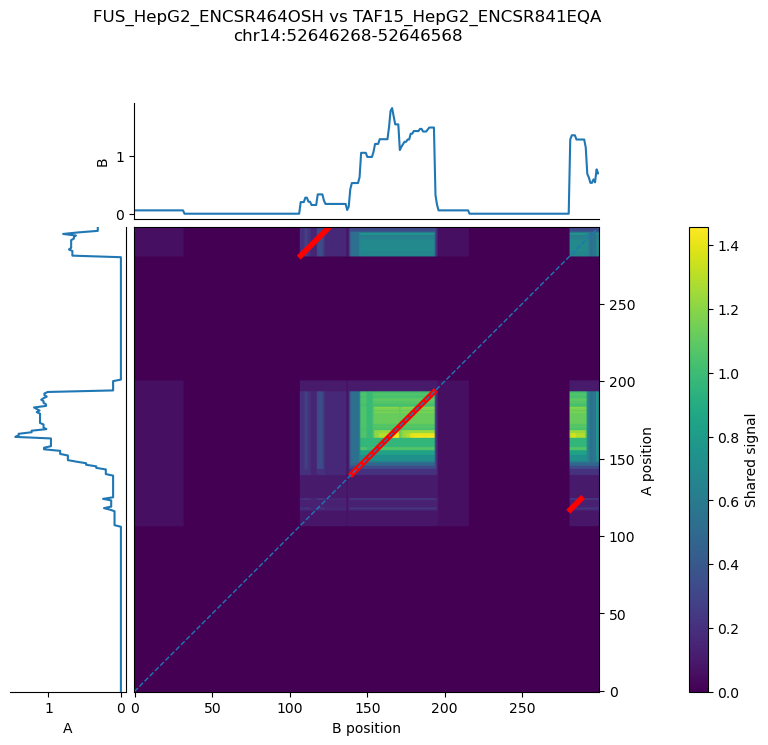

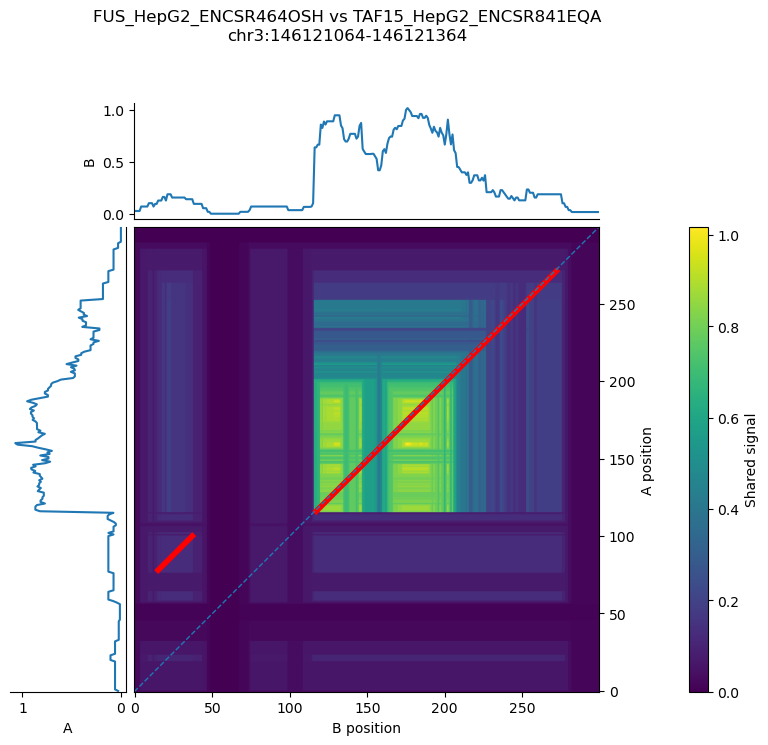

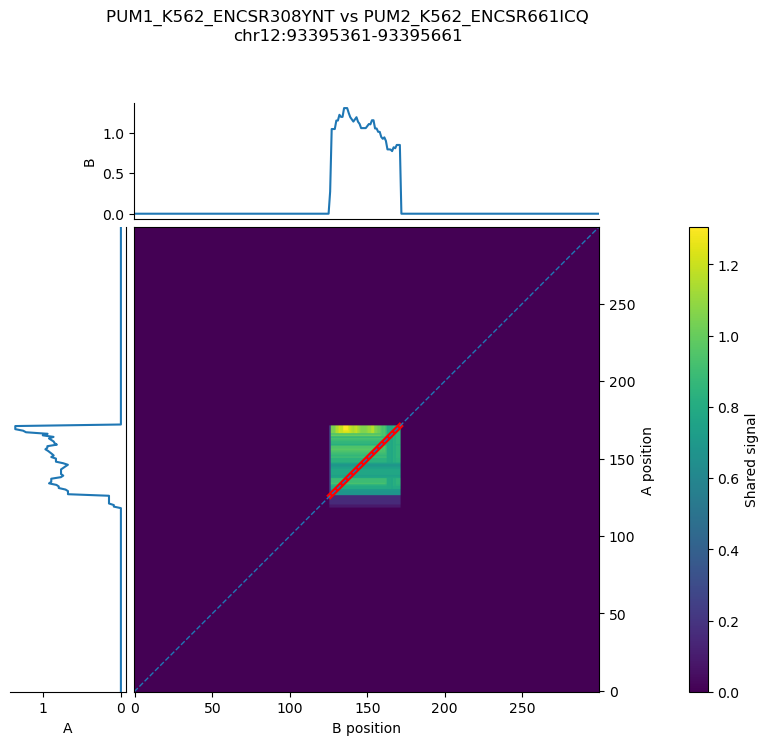

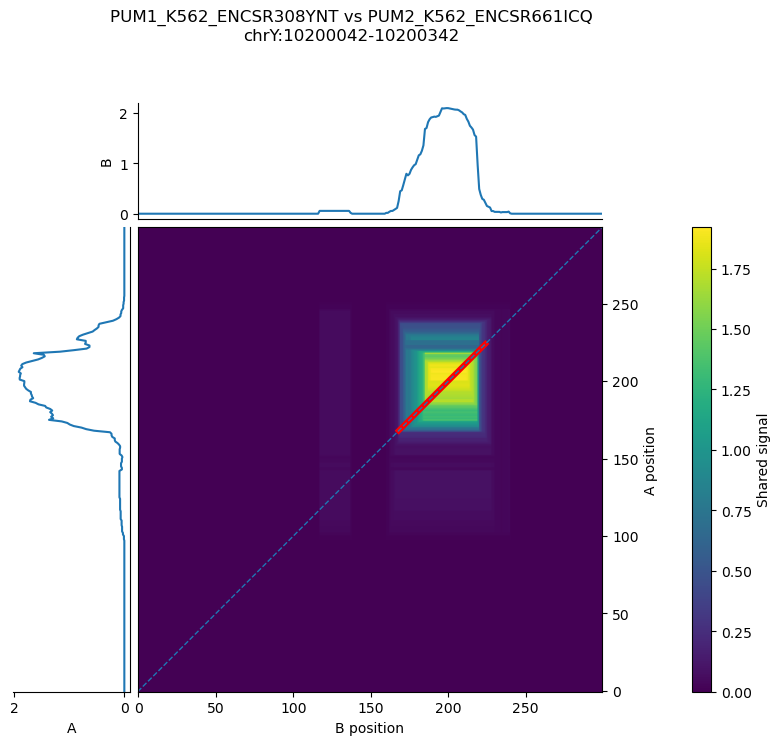

In [9]:
plot_category("easy_agreement")

# Notes

- Of course it is an alignment problem. As a bioinformatician, how did I never think of that before? Did Pavel teach me nothing? I might actually have to look back at some old material for that, may be some useful notes, or stuff that can speed up the problem. 

- That first one I looked at brings up an interesting complex. Let's assume we select that main one as being the main one. In that case, we know for a FACT that there is only one other option for the second one. Like, there are those little bits at the ends that 